In [1]:
import time
import math
import matplotlib.pyplot as plt
from dds import DDS

class PID_Controller:
    def __init__(self, kp, ki, kd, max_output, static_comp=0.0):
        self.kp = kp
        self.ki = ki
        self.kd = kd
        self.max_output = max_output
        self.static_comp = static_comp
        self.integral = 0
        self.prev_error = 0

    def evaluate(self, delta_t, error, target_v=0.0):
        self.integral += error * delta_t
        self.integral = max(-self.max_output, min(self.max_output, self.integral))

        derivative = (error - self.prev_error) / delta_t if delta_t > 0 else 0
        self.prev_error = error

        output = (self.kp * error) + (self.ki * self.integral) + (self.kd * derivative)

        # Se dobbiamo muoverci (target_v > 0) ma l'output non basta a vincere l'attrito statico, alzalo
        if target_v > 0.05 and 0 < output < self.static_comp:
            output = self.static_comp

        return max(-self.max_output, min(self.max_output, output))

class PolarController:
    def __init__(self, kp_linear, vmax, kp_angular, alpha_max):
        self.kp_linear = kp_linear
        self.vmax = vmax
        self.kp_angular = kp_angular
        self.alpha_max = alpha_max

    def evaluate(self, target_x, target_y, pose_x, pose_y, pose_theta):
        dx = target_x - pose_x
        dy = target_y - pose_y
        distance = math.hypot(dx, dy)

        target_angle = math.atan2(dy, dx)
        angle_error = target_angle - pose_theta
        # Normalizzazione dell'angolo tra -pi e +pi
        angle_error = (angle_error + math.pi) % (2 * math.pi) - math.pi

        stop_radius = 1.5
        slow_radius = 4.0

        if distance < stop_radius:
            target_v = 0.0
            target_steering = 0.0
        else:
            target_v = min(self.kp_linear * distance, self.vmax)
            if distance < slow_radius:
                target_v *= (distance - stop_radius) / (slow_radius - stop_radius)
            target_steering = max(-self.alpha_max, min(self.alpha_max, self.kp_angular * angle_error))

        # Riduci la velocità lineare se il robot deve curvare molto
        turn_factor = max(0.2, 1 - abs(angle_error) / self.alpha_max)
        target_v *= turn_factor

        return target_v, target_steering




In [ ]:
dds = DDS()
dds.start('127.0.0.1', 4444)
dds.subscribe(['tick', 'X', 'Z', 'Yaw', 'Speed'])

# Inizializzazione controllori
speed_controller = PID_Controller(kp=15.0, ki=0.0, kd=0.0, max_output=200.0, static_comp=42.0)
polar_controller = PolarController(kp_linear=4.5, vmax=3.0, kp_angular=5.0, alpha_max=math.radians(35))

# Coordinate Target
target_x = 5.0
target_y = 5.0 

# Liste per lo stoccaggio dati (per i grafici)
d_time = []
d_target_speed = []
d_current_speed = []
d_steering = []
d_distance = []
d_angle_error = []

print("Avvio controllo robot...")
start_time = time.time()

try:
    while True:
        delta_t = dds.wait('tick')
        if delta_t is None:
            continue
            
        t_elapsed = time.time() - start_time
        if t_elapsed > 20: # Ferma il test dopo 60 secondi
            break

        # Lettura telemetria da Godot
        x = dds.read('X')
        y = dds.read('Y')
        yaw = dds.read('Yaw') # Godot invia in gradi
        current_speed = dds.read('Speed')

        if None in (x, y, yaw, current_speed):
            continue

        # --- FIX: CONVERSIONE IN RADIANTI ---
        # Convertiamo il valore grezzo di Godot in radianti per usarlo nella matematica del controllore
        yaw = math.radians(yaw)
        # ------------------------------------

        # A. Controllore di Posizione (Restituisce v_target e angolo di sterzo)
        target_v, target_steering = polar_controller.evaluate(target_x, target_y, x, y, yaw)

        # Calcolo di distanza ed errore angolare per i log e per l'arresto
        dist_to_target = math.hypot(target_x - x, target_y - y)
        target_angle = math.atan2(target_y - y, target_x - x)
        angle_error = (target_angle - yaw + math.pi) % (2 * math.pi) - math.pi

        print(f"Errore Angolare pulito: {math.degrees(angle_error):.2f}")

        # Controlla se siamo arrivati
        arrived = dist_to_target < 1.5 and current_speed < 0.1

        if arrived:
            print(f"Target raggiunto a t={t_elapsed:.2f}s")
            break

        # B. Controllore di Velocità (PID converte l'errore di velocità in Coppia Motore)
        speed_error = target_v - current_speed
        torque = speed_controller.evaluate(delta_t, speed_error, target_v)

        # C. Invio comandi a Godot
        dds.publish('Torque', torque, DDS.DDS_TYPE_FLOAT)
        # A Godot inviamo indietro lo sterzo in gradi
        dds.publish('Theta', math.degrees(target_steering), DDS.DDS_TYPE_FLOAT)

        # D. Salvataggio Dati per Plot
        d_time.append(t_elapsed)
        d_target_speed.append(target_v)
        d_current_speed.append(current_speed)
        d_steering.append(math.degrees(target_steering))
        d_distance.append(dist_to_target)
        d_angle_error.append(math.degrees(angle_error))

except KeyboardInterrupt:
    print("Interrotto.")

# Arresto di sicurezza e chiusura
dds.publish('Torque', 0.0, DDS.DDS_TYPE_FLOAT)
dds.publish('Theta', 0.0, DDS.DDS_TYPE_FLOAT)
dds.stop()
print("Test concluso.")



Avvio controllo robot...
Errore Angolare pulito: 47.36
Errore Angolare pulito: 47.36
Errore Angolare pulito: 47.36
Errore Angolare pulito: 47.36
Errore Angolare pulito: 47.36
Errore Angolare pulito: 47.36
Errore Angolare pulito: 47.36
Errore Angolare pulito: 47.36
Errore Angolare pulito: 47.36
Errore Angolare pulito: 47.37
Errore Angolare pulito: 47.37
Errore Angolare pulito: 47.38
Errore Angolare pulito: 47.38
Errore Angolare pulito: 47.38
Errore Angolare pulito: 47.39
Errore Angolare pulito: 47.40
Errore Angolare pulito: 47.41
Errore Angolare pulito: 47.43
Errore Angolare pulito: 47.42
Errore Angolare pulito: 47.45
Errore Angolare pulito: 47.44
Errore Angolare pulito: 47.47
Errore Angolare pulito: 47.47
Errore Angolare pulito: 47.48
Errore Angolare pulito: 47.49
Errore Angolare pulito: 47.51
Errore Angolare pulito: 47.51
Errore Angolare pulito: 47.56
Errore Angolare pulito: 47.57
Errore Angolare pulito: 47.59
Errore Angolare pulito: 47.59
Errore Angolare pulito: 47.61
Errore Angolare

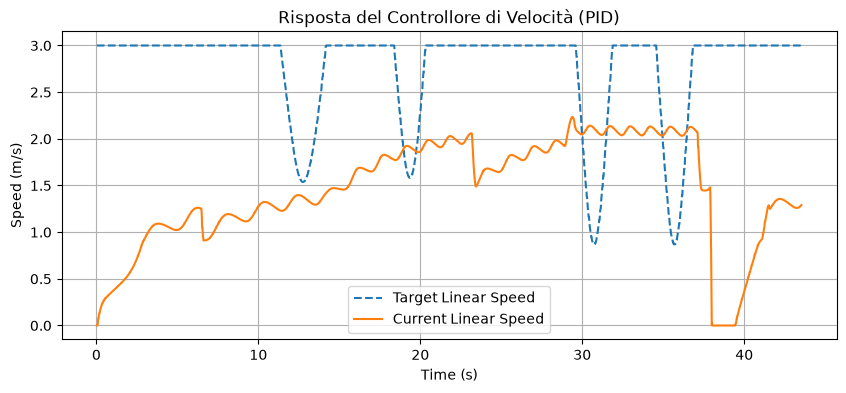

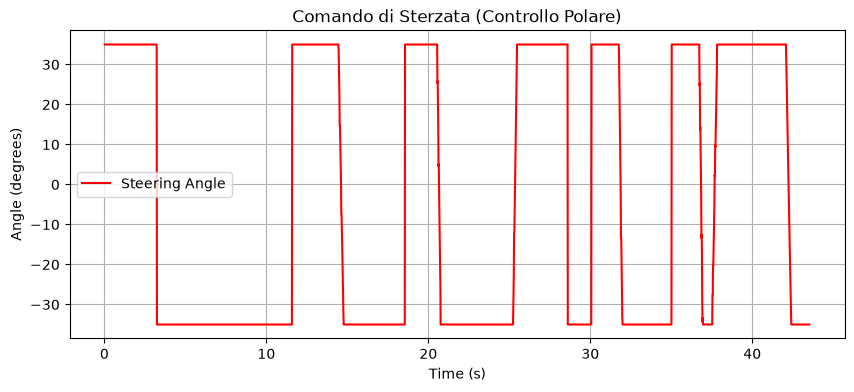

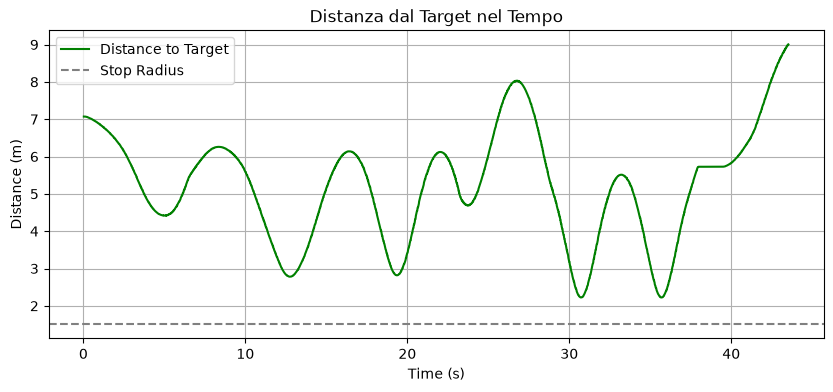

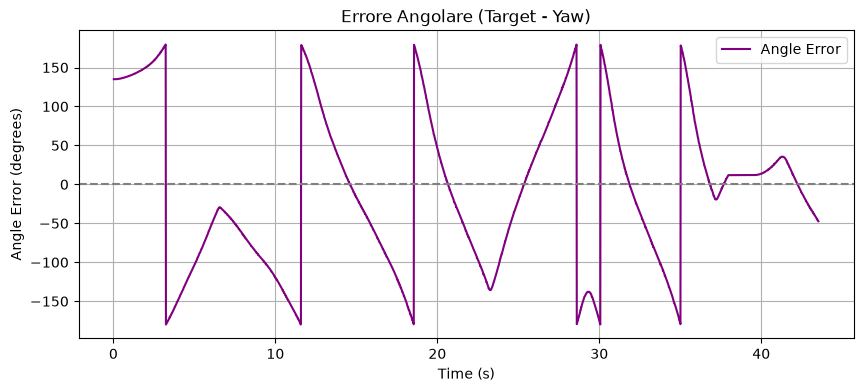

In [27]:
# ==========================================================
# GRAFICI (MATPLOTLIB)
# ==========================================================

# 1. Grafico della Velocità (PID Tuning)
plt.figure(figsize=(10, 4))
plt.plot(d_time, d_target_speed, label="Target Linear Speed", linestyle='--')
plt.plot(d_time, d_current_speed, label="Current Linear Speed")
plt.title("Risposta del Controllore di Velocità (PID)")
plt.xlabel("Time (s)")
plt.ylabel("Speed (m/s)")
plt.legend()
plt.grid(True)
plt.show()

# 2. Grafico dello Sterzo (Polar Control)
plt.figure(figsize=(10, 4))
plt.plot(d_time, d_steering, label="Steering Angle", color='red')
plt.title("Comando di Sterzata (Controllo Polare)")
plt.xlabel("Time (s)")
plt.ylabel("Angle (degrees)")
plt.legend()
plt.grid(True)
plt.show()

# 3. Grafico Distanza dal Target
plt.figure(figsize=(10, 4))
plt.plot(d_time, d_distance, label="Distance to Target", color='green')
plt.axhline(y=1.5, color='gray', linestyle='--', label="Stop Radius")
plt.title("Distanza dal Target nel Tempo")
plt.xlabel("Time (s)")
plt.ylabel("Distance (m)")
plt.legend()
plt.grid(True)
plt.show()

# 4. Grafico dell'Errore Angolare
plt.figure(figsize=(10, 4))
plt.plot(d_time, d_angle_error, label="Angle Error", color='purple')
plt.axhline(y=0, color='gray', linestyle='--')
plt.title("Errore Angolare (Target - Yaw)")
plt.xlabel("Time (s)")
plt.ylabel("Angle Error (degrees)")
plt.legend()
plt.grid(True)
plt.show()